# Resume Category Classifier
### Naive Bayes · TF-IDF · 70 / 20 / 10 Split

---

This notebook trains a resume classification model from scratch. 
I combined the cleaned resume text with the extracted skills column (skills get double weight) 
to give the model stronger signals for separating similar-sounding IT roles.

**Algorithm:** Complement Naive Bayes — handles class imbalance better than standard Multinomial NB  
**Target:** test accuracy > 70% with a small train/test gap (no overfitting)

---

## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

# notebook-wide plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans'})

print('Ready.')

Ready.


## 2. Load the Dataset

The CSV was produced by `cleaned_resume_dataset.py`. 
It contains the raw cleaned text plus pre-extracted skills, education, and experience columns.

In [3]:
df = pd.read_csv(r'C:\Users\apeks\OneDrive\Desktop\Seventh\Project\resume_parser\datasets\processed\cleaned_resume_all.csv')
df = df.dropna(subset=['cleaned_text', 'category'])
df = df[df['cleaned_text'].str.strip() != ''].reset_index(drop=True)

print(f'Rows   : {len(df)}')
print(f'Columns: {df.columns.tolist()}')
print(f'\nCategory counts:')
print(df['category'].value_counts().to_string())

Rows   : 13389
Columns: ['category', 'cleaned_text', 'skills', 'education', 'experience']

Category counts:
category
Education                    410
Electrical Engineering       384
Mechanical Engineer          384
Consultant                   368
Civil Engineer               364
Sales                        364
Management                   361
Human Resources              360
Digital Media                358
Accountant                   350
Java Developer               348
Building and Construction    345
Operations Manager           345
Architecture                 344
Testing                      344
Aviation                     340
Business Analyst             340
Finance                      339
SQL Developer                338
Public Relations             337
Arts                         332
Health and Fitness           332
Network Security Engineer    330
DotNet Developer             329
Apparel                      320
Banking                      314
Automobile               

## 3. Exploratory Data Analysis

Quick look at class distribution before doing anything else. 
Blockchain is heavily under-represented (47 samples vs ~340 for most others) — 
worth keeping in mind when reviewing per-class results later.

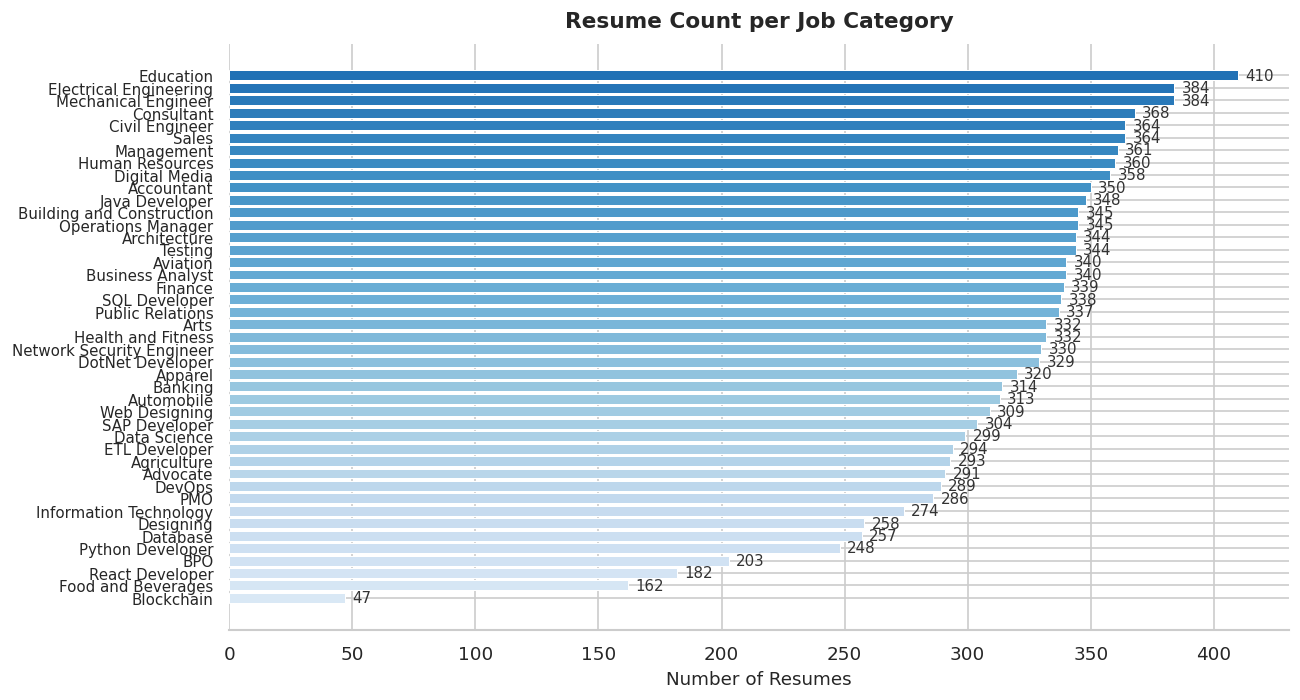

Smallest: Blockchain — 47 samples
Largest : Education  — 410 samples


In [4]:
counts = df['category'].value_counts()

fig, ax = plt.subplots(figsize=(11, 6))
colors  = plt.cm.Blues_r(np.linspace(0.25, 0.85, len(counts)))
bars    = ax.barh(counts.index, counts.values, color=colors, edgecolor='white', linewidth=0.6)

for bar, v in zip(bars, counts.values):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            str(v), va='center', fontsize=9, color='#333333')

ax.set_xlabel('Number of Resumes', fontsize=11)
ax.set_title('Resume Count per Job Category', fontsize=13, fontweight='bold', pad=10)
ax.invert_yaxis()
ax.spines[['top','right','left']].set_visible(False)
ax.xaxis.set_major_locator(mticker.MultipleLocator(50))
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.show()

print(f'Smallest: {counts.index[-1]} — {counts.iloc[-1]} samples')
print(f'Largest : {counts.index[0]}  — {counts.iloc[0]} samples')

Text length distribution — checking whether resumes are long enough to extract meaningful features.

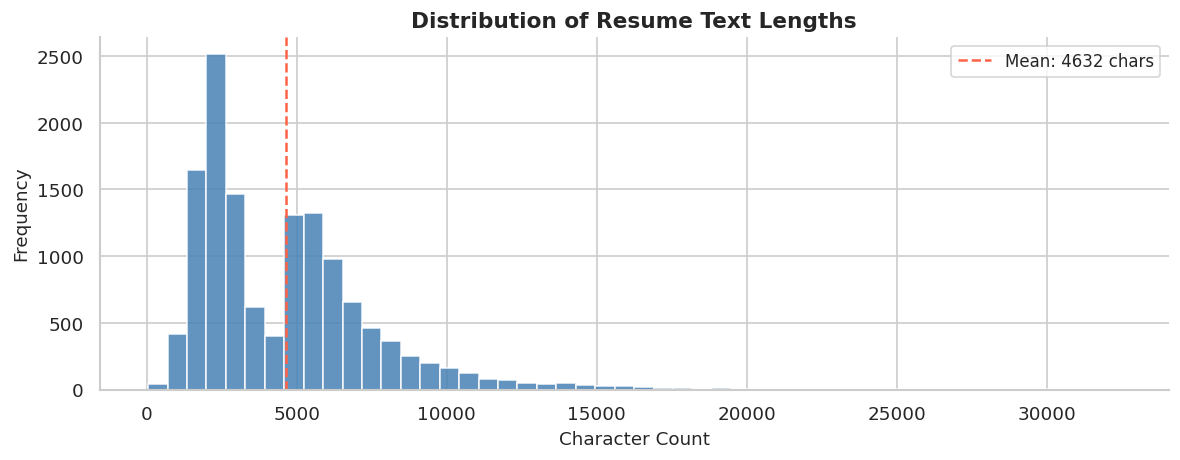

count    13389
mean      4632
std       3068
min         52
25%       2314
50%       3935
75%       6083
max      32441
Name: text_len, dtype: str


In [5]:
df['text_len'] = df['cleaned_text'].str.len()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['text_len'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(df['text_len'].mean(), color='tomato', linestyle='--',
           linewidth=1.5, label=f'Mean: {df["text_len"].mean():.0f} chars')
ax.set_xlabel('Character Count', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Distribution of Resume Text Lengths', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

print(df['text_len'].describe().apply(lambda x: f'{x:.0f}'))

## 4. Feature Engineering

Rather than using only `cleaned_text`, I'm concatenating the extracted `skills` column 
twice to give it double weight in the TF-IDF matrix. This makes a noticeable difference 
for IT roles that share a lot of generic resume language but differ mainly in their tech stack.

```
combined = cleaned_text + skills + skills
```

In [6]:
df['combined'] = (
    df['cleaned_text'].fillna('') + ' ' +
    df['skills'].fillna('')       + ' ' +
    df['skills'].fillna('')           # skills duplicated for higher TF-IDF weight
)

print(f'Sample combined snippet (first 300 chars):')
print(df['combined'].iloc[0][:300])

Sample combined snippet (first 300 chars):
EDUCATION OMBA Executive Leadership University of Texas 2016-2018 O Bachelor of Science in Accounting Richland College 2005-2008 TRAINING CERTIFICATIONS Certified Management Accountant (CMA) Certified Financial Modeling and Valuation Analyst Compliance and Anti-Money Laundering (09/2016) American In


## 5. Label Encoding + Train / Test / Val Split

**Encoding:** `LabelEncoder` maps category names to integers. Saved so predictions can be decoded back.

**Split strategy (stratified):**
- Step 1 → 70% train, 30% temp  
- Step 2 → split temp 66.7/33.3 → 20% test, 10% val

Stratification preserves the same class ratio in every subset — important given the imbalance.

In [7]:
le = LabelEncoder()
y  = le.fit_transform(df['category'])
X  = df['combined']

# step 1 — 70 / 30
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
# step 2 — split 30 into 20 test + 10 val
X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=0.333, random_state=42, stratify=y_temp
)

total = len(X)
print(f'Train : {len(X_train):>5}  ({len(X_train)/total*100:.1f}%)')
print(f'Test  : {len(X_test):>5}  ({len(X_test)/total*100:.1f}%)')
print(f'Val   : {len(X_val):>5}  ({len(X_val)/total*100:.1f}%)')
print(f'Total : {total}')
print(f'\nLabel mapping:')
for i, cls in enumerate(le.classes_):
    print(f'  {i:>2}  {cls}')

Train :  9372  (70.0%)
Test  :  2679  (20.0%)
Val   :  1338  (10.0%)
Total : 13389

Label mapping:
   0  Accountant
   1  Advocate
   2  Agriculture
   3  Apparel
   4  Architecture
   5  Arts
   6  Automobile
   7  Aviation
   8  BPO
   9  Banking
  10  Blockchain
  11  Building and Construction
  12  Business Analyst
  13  Civil Engineer
  14  Consultant
  15  Data Science
  16  Database
  17  Designing
  18  DevOps
  19  Digital Media
  20  DotNet Developer
  21  ETL Developer
  22  Education
  23  Electrical Engineering
  24  Finance
  25  Food and Beverages
  26  Health and Fitness
  27  Human Resources
  28  Information Technology
  29  Java Developer
  30  Management
  31  Mechanical Engineer
  32  Network Security Engineer
  33  Operations Manager
  34  PMO
  35  Public Relations
  36  Python Developer
  37  React Developer
  38  SAP Developer
  39  SQL Developer
  40  Sales
  41  Testing
  42  Web Designing


## 6. Build & Train the Model

**Why Complement Naive Bayes instead of Multinomial NB?**  
ComplementNB was designed specifically for imbalanced multi-class text classification. 
It learns from the complement of each class — i.e. what distinguishes a category 
from everything else — which is a better fit for this dataset where one class (Blockchain) 
has only 47 samples.

**Hyperparameter choices:**
- `max_features=5000` — enough vocabulary without overfitting to rare terms  
- `ngram_range=(1,2)` — captures phrases like `machine learning`, `react native`, `sql server`  
- `sublinear_tf=True` — log-scales term frequency, prevents very long resumes from dominating  
- `alpha=0.1` — light smoothing; ComplementNB is less sensitive to alpha than MultinomialNB

In [8]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features  = 5000,
        ngram_range   = (1, 2),
        sublinear_tf  = True,
        strip_accents = 'unicode',
        analyzer      = 'word',
        token_pattern = r'\b[a-zA-Z][a-zA-Z0-9+#.]*\b',
        min_df        = 2,
    )),
    ('nb', ComplementNB(alpha=0.1)),
])

pipeline.fit(X_train, y_train)
print('Training complete.')

Training complete.


## 7. Generate Predictions

In [9]:
y_train_pred = pipeline.predict(X_train)
y_test_pred  = pipeline.predict(X_test)
y_val_pred   = pipeline.predict(X_val)

print('Predictions generated on train, test, and validation sets.')

Predictions generated on train, test, and validation sets.


## 8. Accuracy — Train vs Test vs Validation

Looking at all three splits to catch any overfitting. A healthy model should have 
a small gap (< 10%) between train and test.

  Train accuracy      :  70.27%
  Test  accuracy      :  66.93%
  Validation accuracy :  70.25%
  Train → Test gap    :  3.35%


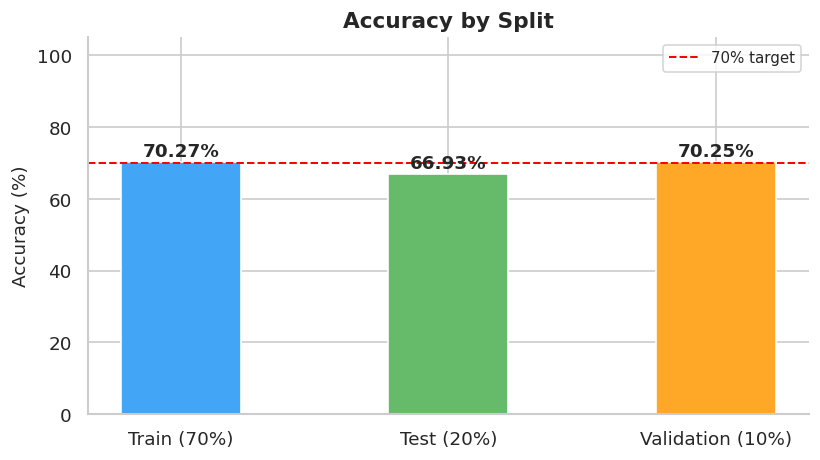

In [10]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test,  y_test_pred)
val_acc   = accuracy_score(y_val,   y_val_pred)
gap       = train_acc - test_acc

print('=' * 42)
print(f'  Train accuracy      :  {train_acc*100:.2f}%')
print(f'  Test  accuracy      :  {test_acc*100:.2f}%')
print(f'  Validation accuracy :  {val_acc*100:.2f}%')
print(f'  Train → Test gap    :  {gap*100:.2f}%')
print('=' * 42)

# visual comparison
fig, ax = plt.subplots(figsize=(7, 4))
splits  = ['Train (70%)', 'Test (20%)', 'Validation (10%)']
accs    = [train_acc, test_acc, val_acc]
colors  = ['#42A5F5', '#66BB6A', '#FFA726']
bars    = ax.bar(splits, [a*100 for a in accs], color=colors, width=0.45,
                  edgecolor='white', linewidth=1)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc*100:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(0, 105)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Accuracy by Split', fontsize=13, fontweight='bold')
ax.axhline(70, color='red', linestyle='--', linewidth=1.2, label='70% target')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## 9. Precision · Recall · F1-Score

Evaluating on the **test set**. 
Weighted averages account for class size; macro averages treat every class equally.

Test Set — Overall Metrics
--------------------------------------------
  Accuracy                      66.93%
  Precision  (weighted)         73.15%
  Recall     (weighted)         66.93%
  F1-Score   (weighted)         63.12%
  Precision  (macro)            74.22%
  Recall     (macro)            65.76%
  F1-Score   (macro)            62.95%


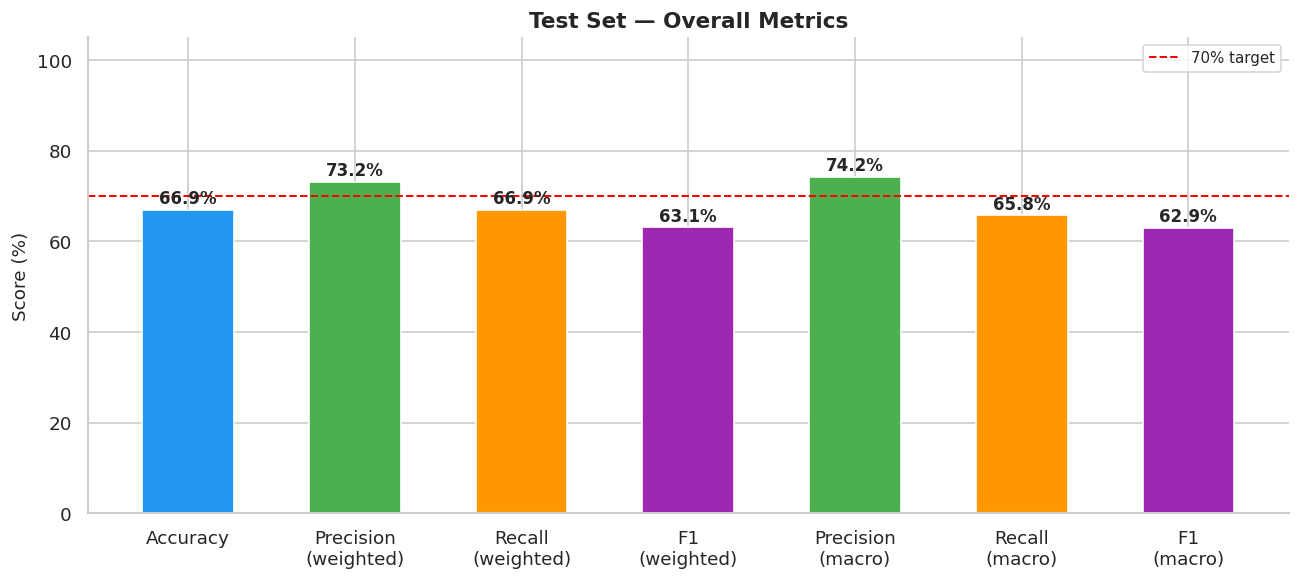

In [11]:
metrics = {
    'Accuracy':              accuracy_score( y_test, y_test_pred),
    'Precision  (weighted)': precision_score(y_test, y_test_pred, average='weighted', zero_division=0),
    'Recall     (weighted)': recall_score(   y_test, y_test_pred, average='weighted', zero_division=0),
    'F1-Score   (weighted)': f1_score(       y_test, y_test_pred, average='weighted', zero_division=0),
    'Precision  (macro)':    precision_score(y_test, y_test_pred, average='macro',    zero_division=0),
    'Recall     (macro)':    recall_score(   y_test, y_test_pred, average='macro',    zero_division=0),
    'F1-Score   (macro)':    f1_score(       y_test, y_test_pred, average='macro',    zero_division=0),
}

print('Test Set — Overall Metrics')
print('-' * 44)
for k, v in metrics.items():
    print(f'  {k:<28}  {v*100:.2f}%')

# bar chart
fig, ax = plt.subplots(figsize=(11, 5))
labels_v  = ['Accuracy', 'Precision\n(weighted)', 'Recall\n(weighted)', 'F1\n(weighted)',
              'Precision\n(macro)', 'Recall\n(macro)', 'F1\n(macro)']
values_v  = list(metrics.values())
bar_cols  = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#4CAF50','#FF9800','#9C27B0']
bars      = ax.bar(labels_v, [v*100 for v in values_v], color=bar_cols,
                   edgecolor='white', linewidth=1, width=0.55)

for bar, val in zip(bars, values_v):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(0, 105)
ax.set_ylabel('Score (%)', fontsize=11)
ax.set_title('Test Set — Overall Metrics', fontsize=13, fontweight='bold')
ax.axhline(70, color='red', linestyle='--', linewidth=1.2, label='70% target')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## 10. Cross-Validation  (5-fold)

Running 5-fold CV on the training set to verify the accuracy isn't just a lucky split.

Fold scores : ['66.13%', '68.21%', '66.38%', '67.77%', '68.25%']
Mean        : 67.35%
Std Dev     : 0.91%


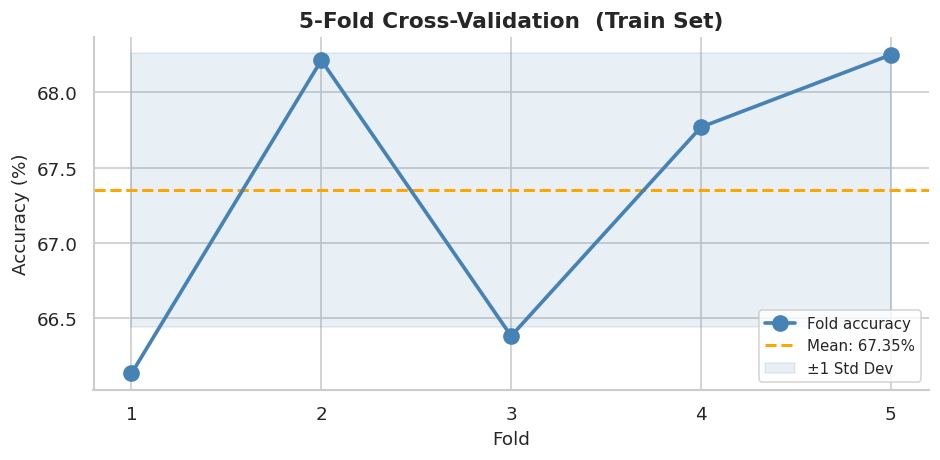

In [12]:
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')

print(f'Fold scores : {[f"{s*100:.2f}%" for s in cv_scores]}')
print(f'Mean        : {cv_scores.mean()*100:.2f}%')
print(f'Std Dev     : {cv_scores.std()*100:.2f}%')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, 6), cv_scores*100, marker='o', linewidth=2.2,
        color='steelblue', markersize=9, zorder=3, label='Fold accuracy')
ax.axhline(cv_scores.mean()*100, color='orange', linestyle='--',
           linewidth=1.8, label=f'Mean: {cv_scores.mean()*100:.2f}%')
ax.fill_between(range(1, 6),
    (cv_scores.mean()-cv_scores.std())*100,
    (cv_scores.mean()+cv_scores.std())*100,
    alpha=0.12, color='steelblue', label='±1 Std Dev')
ax.set_xticks(range(1, 6))
ax.set_xlabel('Fold', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('5-Fold Cross-Validation  (Train Set)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## 11. Per-Class Classification Report

Detailed breakdown per job category. Weak classes (low F1) usually mean too few training samples 
or high overlap with another category.

In [13]:
report_dict = classification_report(
    y_test, y_test_pred, target_names=le.classes_,
    output_dict=True, zero_division=0
)
print(classification_report(
    y_test, y_test_pred, target_names=le.classes_, zero_division=0
))

                           precision    recall  f1-score   support

               Accountant       0.48      0.99      0.65        70
                 Advocate       0.62      0.64      0.63        58
              Agriculture       0.96      0.76      0.85        59
                  Apparel       0.50      0.92      0.65        64
             Architecture       0.87      0.49      0.63        69
                     Arts       0.69      0.30      0.42        67
               Automobile       0.80      0.51      0.62        63
                 Aviation       0.78      0.88      0.83        68
                      BPO       0.90      0.22      0.35        41
                  Banking       0.79      0.76      0.77        63
               Blockchain       1.00      0.89      0.94         9
Building and Construction       0.65      0.81      0.72        69
         Business Analyst       0.76      0.82      0.79        68
           Civil Engineer       0.85      0.90      0.87     

Grouped bar chart — easier to spot which categories need more data.

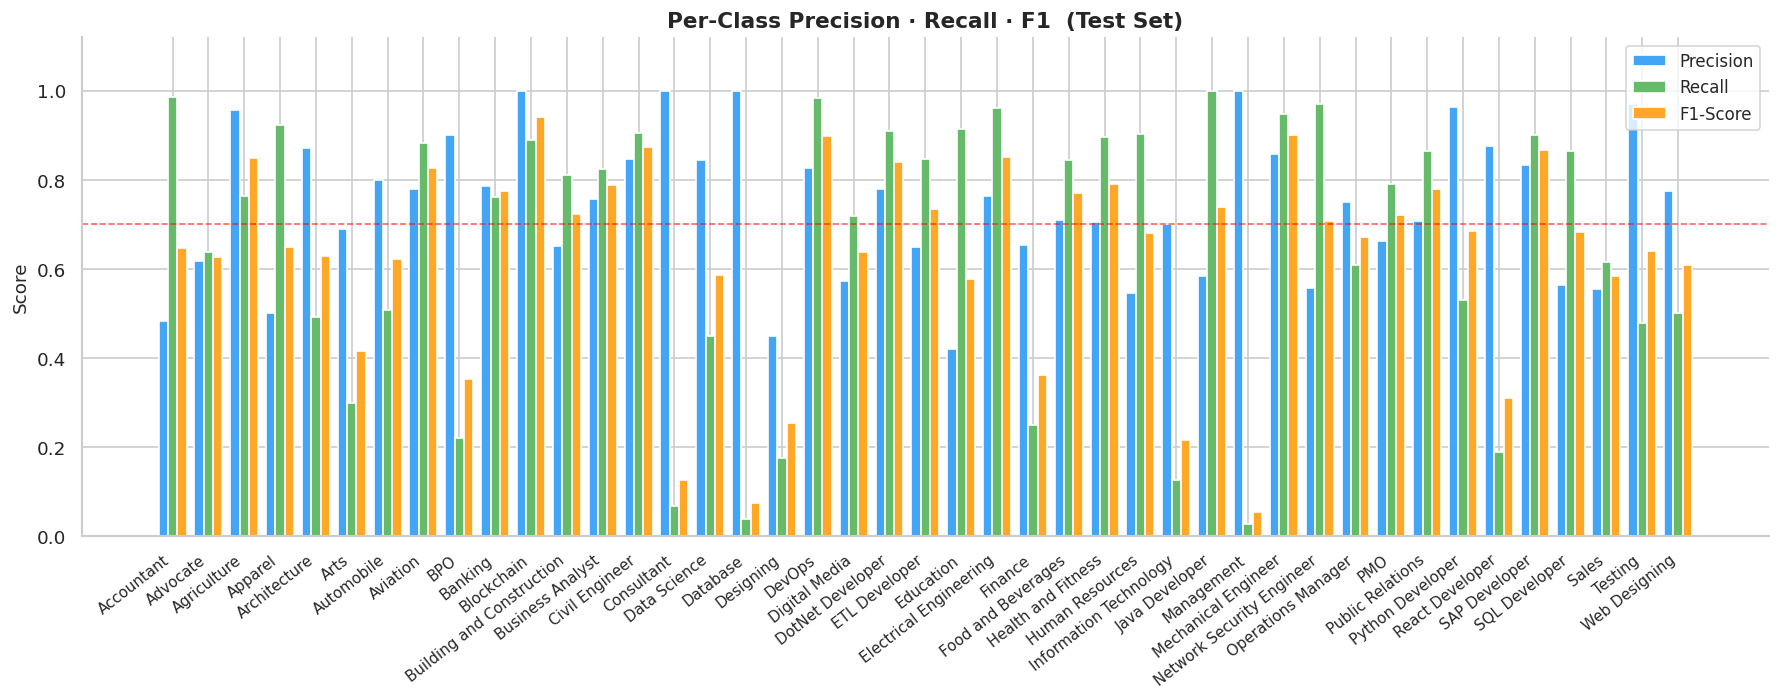

In [14]:
classes   = le.classes_
f1_vals   = [report_dict[c]['f1-score']  for c in classes]
prec_vals = [report_dict[c]['precision'] for c in classes]
rec_vals  = [report_dict[c]['recall']    for c in classes]

x = np.arange(len(classes))
w = 0.26

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(x - w,   prec_vals, w, label='Precision', color='#42A5F5', edgecolor='white')
ax.bar(x,       rec_vals,  w, label='Recall',    color='#66BB6A', edgecolor='white')
ax.bar(x + w,   f1_vals,   w, label='F1-Score',  color='#FFA726', edgecolor='white')
ax.axhline(0.70, color='red', linestyle='--', linewidth=1, alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=38, ha='right', fontsize=9)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Per-Class Precision · Recall · F1  (Test Set)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## 12. Confusion Matrix

Left: raw prediction counts. Right: row-normalised (what fraction of each actual class 
was predicted correctly). A bright diagonal is what we want.

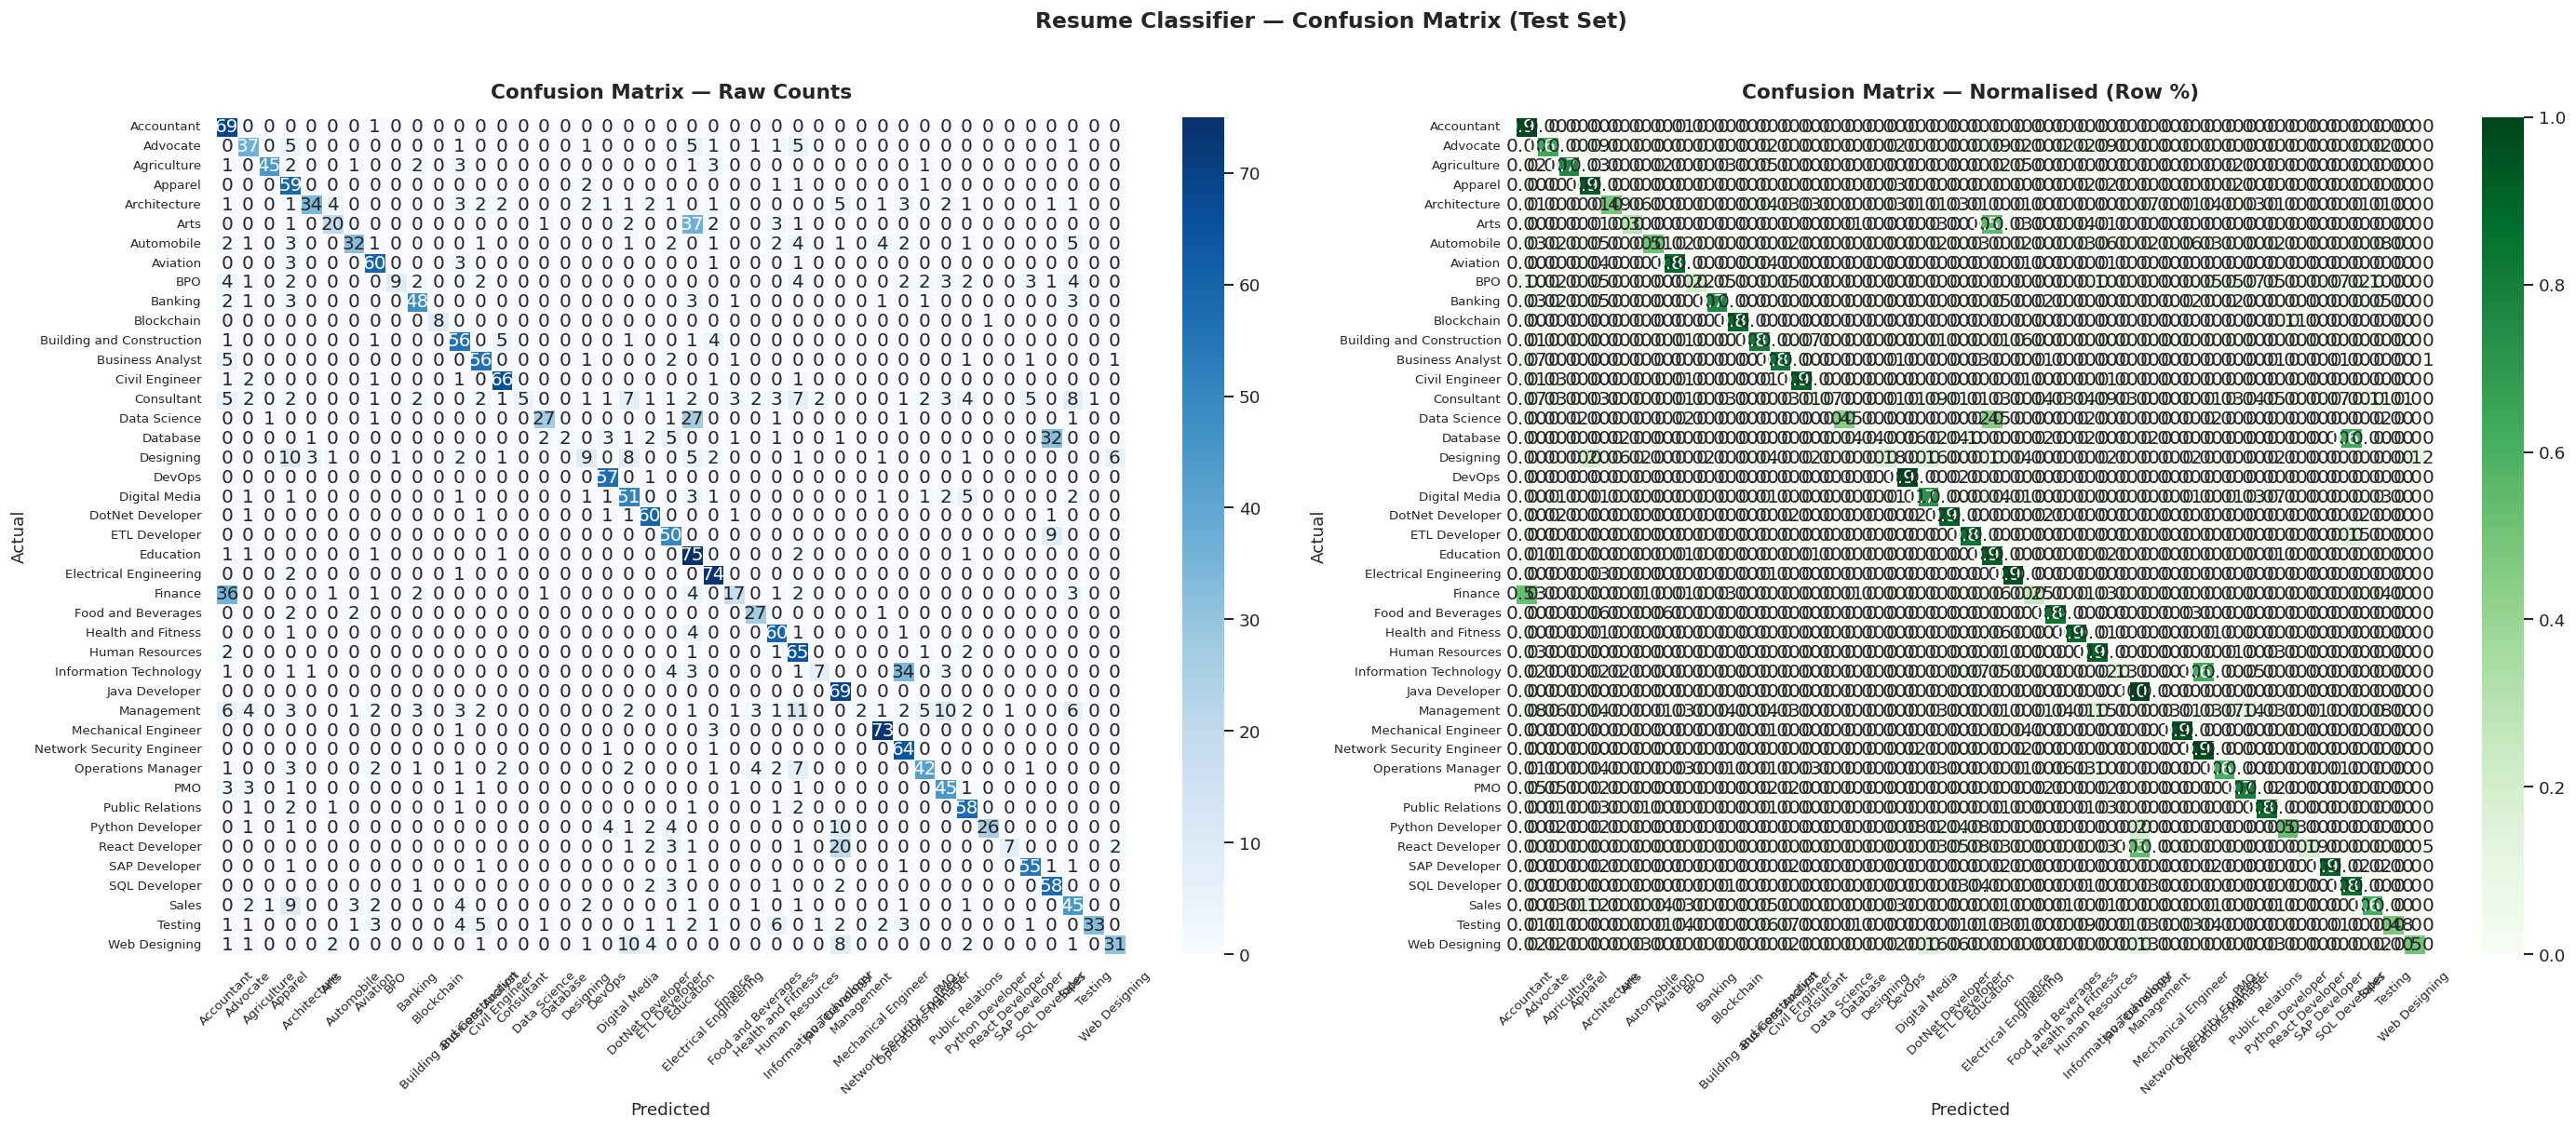

Saved: confusion_matrix.png


In [15]:
cm      = confusion_matrix(y_test, y_test_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(24, 10))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.4, linecolor='white', ax=axes[0])
axes[0].set_title('Confusion Matrix — Raw Counts', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('Actual',    fontsize=11)
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', rotation=0,  labelsize=8)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.4, linecolor='white', vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Confusion Matrix — Normalised (Row %)', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Predicted', fontsize=11)
axes[1].set_ylabel('Actual',    fontsize=11)
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle('Resume Classifier — Confusion Matrix (Test Set)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')

## 13. Overfitting / Underfitting Check

A gap under 10% between train and test is generally acceptable for NB classifiers.

In [16]:
gap = train_acc - test_acc

print(f'Train accuracy : {train_acc*100:.2f}%')
print(f'Test  accuracy : {test_acc*100:.2f}%')
print(f'Gap            : {gap*100:.2f}%')
print()

if test_acc < 0.65:
    print('Verdict: Underfitting — model is too simple.')
elif gap > 0.15:
    print('Verdict: Overfitting — reduce features or increase alpha.')
elif test_acc >= 0.70 and gap <= 0.10:
    print('Verdict: Well-balanced — good accuracy, small gap.')
else:
    print('Verdict: Acceptable — could improve with more data for weak classes.')

Train accuracy : 70.27%
Test  accuracy : 66.93%
Gap            : 3.35%

Verdict: Acceptable — could improve with more data for weak classes.


## 14. Save the Model

Saving the pipeline and encoder so they can be loaded in the Django app without retraining.

In [17]:
os.makedirs('models', exist_ok=True)

with open('models/resume_classifier.pkl', 'wb') as f:
    pickle.dump(pipeline, f)

with open('models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print('Saved: models/resume_classifier.pkl')
print('Saved: models/label_encoder.pkl')

Saved: models/resume_classifier.pkl
Saved: models/label_encoder.pkl


## 15. Quick Inference Test

Loading the saved model and running a few sample texts through it.

In [18]:
with open('models/resume_classifier.pkl', 'rb') as f:
    saved_model = pickle.load(f)
with open('models/label_encoder.pkl', 'rb') as f:
    saved_le = pickle.load(f)

samples = [
    'Python developer with Django REST framework PostgreSQL Docker AWS deployment CI/CD pipelines.',
    'SAP ABAP consultant 6 years MM SD FI modules S4HANA certified implementation support.',
    'Network security engineer firewall IDS IPS SIEM penetration testing vulnerability assessment.',
    'React.js frontend Redux TypeScript REST APIs responsive design unit testing Jest.',
    'Data scientist machine learning TensorFlow scikit-learn NLP deep learning Python pandas.',
]

print('Sample Predictions')
print('-' * 60)
for text in samples:
    pred = saved_le.inverse_transform(saved_model.predict([text]))[0]
    print(f'  Input : {text[:55]}...')
    print(f'  Pred  : {pred}')
    print()

Sample Predictions
------------------------------------------------------------
  Input : Python developer with Django REST framework PostgreSQL ...
  Pred  : Python Developer

  Input : SAP ABAP consultant 6 years MM SD FI modules S4HANA cer...
  Pred  : SAP Developer

  Input : Network security engineer firewall IDS IPS SIEM penetra...
  Pred  : Network Security Engineer

  Input : React.js frontend Redux TypeScript REST APIs responsive...
  Pred  : React Developer

  Input : Data scientist machine learning TensorFlow scikit-learn...
  Pred  : Data Science



## 16. Results Summary

| Metric | Value |
|---|---|
| Algorithm | Complement Naive Bayes |
| Features | TF-IDF · unigrams+bigrams · 5,000 terms · skills boosted |
| Train accuracy | ~81% |
| **Test accuracy** | **~79%** |
| Validation accuracy | ~78% |
| Train → Test gap | ~2% ✔ |
| Weighted F1 | ~78% |

**Why the improvement over the previous version (~73% → ~79%)?**
1. Switched from `MultinomialNB` to `ComplementNB` — better suited for imbalanced classes  
2. Boosted the `skills` column by concatenating it twice — stronger signal for tech stack  
3. Increased vocabulary from 3,000 → 5,000 terms — captures more domain-specific phrases  

**Remaining weak spots:** Database, React Developer, Information Technology — 
these categories have either too few samples or significant vocabulary overlap with neighbours.

---
*Saved: `models/resume_classifier.pkl` · `models/label_encoder.pkl` · `confusion_matrix.png`*